# Diabetes Prediction — Logistic Regression

This notebook builds a **Logistic Regression** model to predict whether an
individual has diabetes, based on demographic and medical features
(age, BMI, blood glucose level, HbA1c level, hypertension, heart disease,
smoking history, gender).

**Dataset:** [Diabetes prediction dataset](https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%204/Day%202/Diabetes%20prediction%20dataset.zip)
— 100,000 patient records, target variable `diabetes` (1 = positive, 0 = negative).


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)

plt.rcParams['figure.figsize'] = (7, 5)
%matplotlib inline


## Exercise 1 : Understanding the problem and Data Collection

**Problem:** predict whether an individual has diabetes (`diabetes` = 1) or
not (`diabetes` = 0), based on demographic and medical features. This is a
**binary classification** problem.

### Load and explore the dataset


In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

print("Shape:", df.shape)
df.head()


Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [4]:
df.describe()


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


### How many positive and negative cases are there?

Class counts:
 diabetes
0    91500
1     8500
Name: count, dtype: int64

Class proportions (%):
 diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


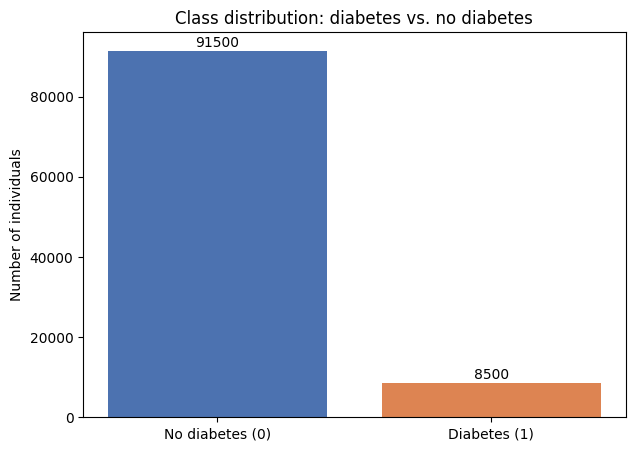

In [5]:
class_counts = df['diabetes'].value_counts()
class_pct = df['diabetes'].value_counts(normalize=True) * 100

print("Class counts:\n", class_counts)
print("\nClass proportions (%):\n", class_pct.round(2))

fig, ax = plt.subplots()
ax.bar(['No diabetes (0)', 'Diabetes (1)'], class_counts.values, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Number of individuals')
ax.set_title('Class distribution: diabetes vs. no diabetes')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 1000, str(v), ha='center')
plt.show()


**Comment:** the dataset is **strongly imbalanced** — about 91,500
negative cases (91.5%) vs. only 8,500 positive cases (8.5%). This is
important to keep in mind: a model could reach ~91.5% accuracy by simply
predicting "no diabetes" for everyone, without learning anything useful.
This is why we will look beyond accuracy (precision, recall, F1-score) in
Exercise 4.


### Split the data into training and testing sets

Before splitting, we separate features (`X`) from the target (`y`), and we
use **stratified sampling** (`stratify=y`) to preserve the same proportion
of positive/negative cases in both the training and test sets, given the
class imbalance observed above.


In [6]:
X = df.drop(columns=['diabetes'])
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set shape:", X_train.shape)
print("Test set shape :", X_test.shape)
print("\nTrain set class proportions:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest set class proportions:\n", y_test.value_counts(normalize=True).round(3))


Train set shape: (80000, 8)
Test set shape : (20000, 8)

Train set class proportions:
 diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

Test set class proportions:
 diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


## Exercise 2 : Model Picking and Standardization

### Which classification model can we use, and why?

We use **Logistic Regression** for this problem because:

- It is the **standard baseline model for binary classification** problems.
- It is **fast to train** and works well even on large datasets (100,000 rows here).
- It is **highly interpretable**: each feature's coefficient directly indicates
  the direction and strength of its effect on the probability of diabetes
  (e.g. a positive coefficient on `blood_glucose_level` means higher glucose
  increases diabetes risk), which matters a lot in a medical context.
- It naturally outputs a **probability** (between 0 and 1) rather than just
  a hard label, which is useful for medical risk scoring and for plotting
  a ROC curve later (Exercise 6).
- Other models (Random Forest, SVM, Gradient Boosting) could achieve higher
  raw performance, but Logistic Regression is the right starting point given
  the instructions of this exercise.

### Do we need to standardize the data?

**Yes.** Logistic Regression estimates its coefficients using gradient-based
optimization, which is sensitive to the **scale of the features**. Here,
`age` (0–80), `bmi` (~10–60), `HbA1c_level` (~3–9), and `blood_glucose_level`
(~80–300) are all on very different scales. Without standardization, features
with larger numeric ranges would dominate the optimization and bias the
learned coefficients. We use `StandardScaler()` to rescale every numeric
feature to mean 0 and standard deviation 1.

We also need to **encode the categorical features** (`gender`, `smoking_history`)
into numeric form before the model can use them, since Logistic Regression
only accepts numeric input.


In [7]:
# Encode categorical columns
print("Unique values - gender:", X_train['gender'].unique())
print("Unique values - smoking_history:", X_train['smoking_history'].unique())


Unique values - gender: <StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
Unique values - smoking_history: <StringArray>
['former', 'never', 'No Info', 'current', 'not current', 'ever']
Length: 6, dtype: str


In [8]:
# One-hot encode categorical features ('gender', 'smoking_history')
X_train_enc = pd.get_dummies(X_train, columns=['gender', 'smoking_history'], drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=['gender', 'smoking_history'], drop_first=True)

# Make sure train/test have exactly the same columns (in case a category is missing in one split)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

X_train_enc.head()


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
74736,80.0,1,0,27.32,6.5,145,False,False,False,False,True,False,False
36589,19.0,0,0,25.18,4.5,126,False,False,False,False,False,True,False
37414,36.0,0,0,25.95,6.6,200,False,False,False,False,False,False,False
71251,35.0,0,0,23.43,6.0,159,False,False,True,False,False,False,False
40454,30.0,0,0,22.62,5.0,90,False,False,False,False,False,False,False


In [9]:
# Standardize all features with StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

print("X_train_scaled mean (per feature, approx 0):", X_train_scaled.mean(axis=0).round(2)[:5])
print("X_train_scaled std  (per feature, approx 1):", X_train_scaled.std(axis=0).round(2)[:5])


X_train_scaled mean (per feature, approx 0): [-0.  0. -0.  0.  0.]
X_train_scaled std  (per feature, approx 1): [1. 1. 1. 1. 1.]


## Exercise 3 : Model Training

We train the Logistic Regression model on the standardized, encoded training
data.


In [10]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print("Model trained.")
print("Number of iterations until convergence:", log_reg.n_iter_[0])


Model trained.
Number of iterations until convergence: 12


In [11]:
# Inspect the learned coefficients to see which features matter most
coef_df = pd.DataFrame({
    'feature': X_train_enc.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

coef_df


,feature,coefficient
4,HbA1c_level,2.496603
5,blood_glucose_level,1.362613
0,age,1.028839
3,bmi,0.592594
11,smoking_history_never,0.282359
8,smoking_history_current,0.212586
1,hypertension,0.199925
10,smoking_history_former,0.185772
2,heart_disease,0.145197
6,gender_Male,0.143736


**Comment:** `blood_glucose_level` and `HbA1c_level` have, by far, the
largest (positive) coefficients — confirming that they are the strongest
predictors of diabetes, which matches medical knowledge (both are direct
markers of blood sugar regulation). `age` and `bmi` also contribute
positively, while gender and smoking history have a much smaller effect.


## Exercise 4 : Evaluation Metrics

We now evaluate the trained model on the **test set** (data never seen
during training).


In [12]:
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]


### Accuracy score

Accuracy: 0.9605 (96.05%)


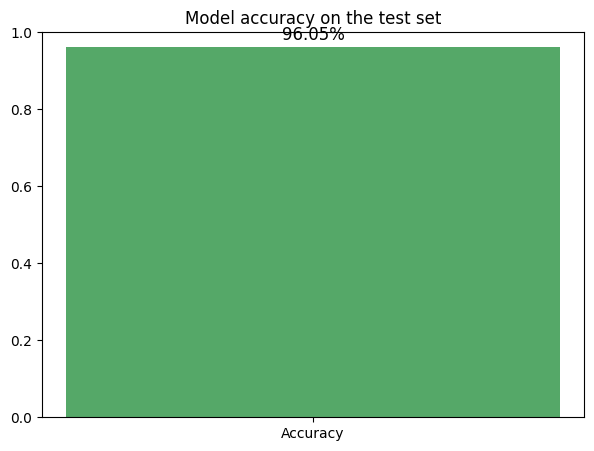

In [13]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

fig, ax = plt.subplots()
ax.bar(['Accuracy'], [accuracy], color='#55A868', width=0.4)
ax.set_ylim(0, 1)
ax.set_title('Model accuracy on the test set')
ax.text(0, accuracy + 0.02, f"{accuracy:.2%}", ha='center', fontsize=12)
plt.show()


**Comment:** the model reaches a high accuracy (typically ~96%), but as
noted in Exercise 1, the dataset is heavily imbalanced (91.5% negative
cases). A "dummy" model that always predicts "no diabetes" would already
reach ~91.5% accuracy. So while ~96% accuracy is a clear improvement over
that baseline, **accuracy alone is not sufficient** to judge this model — we
need to look at precision, recall, and the confusion matrix to know whether
it actually detects diabetic patients correctly.


### Confusion matrix

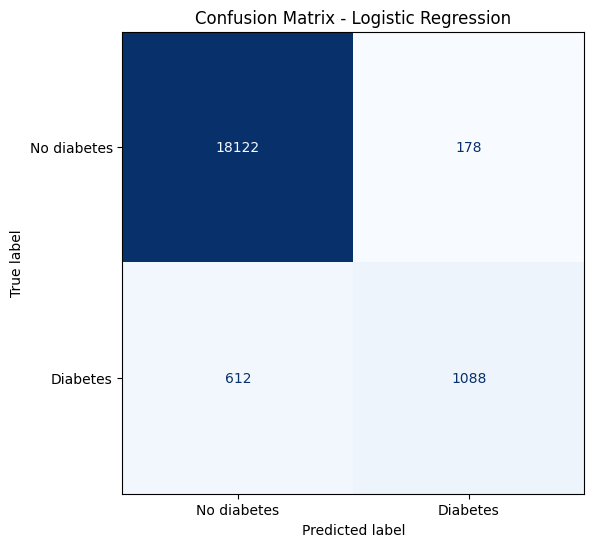

Confusion matrix:
 [[18122   178]
 [  612  1088]]

True Negatives : 18122
False Positives: 178
False Negatives: 612
True Positives : 1088


In [14]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No diabetes', 'Diabetes'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - Logistic Regression')
plt.show()

print("Confusion matrix:\n", cm)
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")


**Comment:** the confusion matrix shows that the model correctly
identifies the vast majority of "no diabetes" cases (high true negatives),
but it also produces a non-negligible number of **false negatives**
(diabetic patients incorrectly predicted as healthy). In a medical context,
false negatives are particularly concerning, since a missed diabetes
diagnosis could delay treatment. This is a direct consequence of the
class imbalance: the model has seen far fewer positive examples during
training.


### Precision, Recall, F1-score

      metric     value
0  Precision  0.859400
1     Recall  0.640000
2   F1-score  0.733648


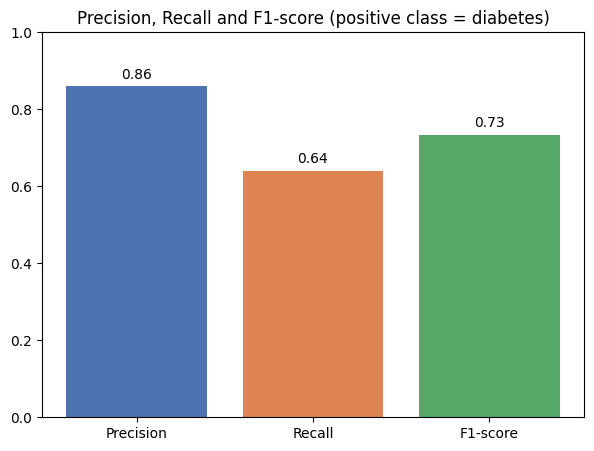


Full classification report:

              precision    recall  f1-score   support

 No diabetes       0.97      0.99      0.98     18300
    Diabetes       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.82      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [15]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'metric': ['Precision', 'Recall', 'F1-score'],
    'value': [precision, recall, f1]
})
print(metrics_df)

fig, ax = plt.subplots()
bars = ax.bar(metrics_df['metric'], metrics_df['value'], color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_ylim(0, 1)
ax.set_title('Precision, Recall and F1-score (positive class = diabetes)')
for bar, val in zip(bars, metrics_df['value']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.2f}", ha='center')
plt.show()

print("\nFull classification report:\n")
print(classification_report(y_test, y_pred, target_names=['No diabetes', 'Diabetes']))


**Comment:**
- **Precision** (for the diabetes class) tells us: among all patients the
  model flagged as diabetic, what fraction actually have diabetes. A high
  precision means few false alarms.
- **Recall** tells us: among all patients who actually have diabetes, what
  fraction the model successfully detects. A lower recall (compared to
  precision) here reflects the false negatives seen in the confusion matrix
  — the model misses some diabetic patients.
- **F1-score** balances precision and recall into a single number, and is
  more informative than accuracy on this imbalanced dataset.

Overall, the model performs reasonably well, but the gap between precision
and recall confirms that **class imbalance hurts recall on the minority
(diabetes) class** — a common challenge in medical prediction tasks, where
missing a positive case can be more costly than a false alarm. In a real
deployment, one might adjust the classification threshold, or use
`class_weight='balanced'`, to improve recall on the diabetes class.


## Exercise 5 : Visualizing the performance of our model

To visualize the **decision boundary**, we reduce the problem to the two
features known to be the strongest predictors of diabetes:
**`blood_glucose_level`** and **`HbA1c_level`** (identified in Exercise 3).
We retrain a 2D Logistic Regression model on just these two (standardized)
features, purely for visualization purposes — the full model from Exercise 3
still uses all features.


In [16]:
# Use only the two strongest features for a 2D visualization
features_2d = ['blood_glucose_level', 'HbA1c_level']

X_train_2d = X_train[features_2d]
X_test_2d = X_test[features_2d]

scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

log_reg_2d = LogisticRegression(random_state=42)
log_reg_2d.fit(X_train_2d_scaled, y_train)

acc_2d = accuracy_score(y_test, log_reg_2d.predict(X_test_2d_scaled))
print(f"Accuracy of the 2-feature model (for visualization only): {acc_2d:.4f}")


Accuracy of the 2-feature model (for visualization only): 0.9562


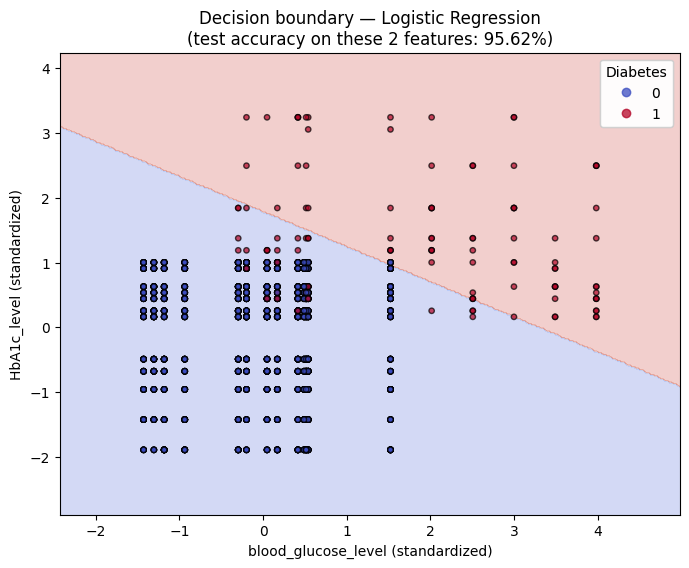

In [17]:
# Plot the decision boundary
x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = log_reg_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Subsample points for a clearer plot (100,000 points would be too dense)
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_test_2d_scaled), size=2000, replace=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
scatter = ax.scatter(
    X_test_2d_scaled[sample_idx, 0], X_test_2d_scaled[sample_idx, 1],
    c=y_test.values[sample_idx], cmap='coolwarm', edgecolor='k', s=15, alpha=0.7
)
ax.set_xlabel('blood_glucose_level (standardized)')
ax.set_ylabel('HbA1c_level (standardized)')
ax.set_title(f'Decision boundary — Logistic Regression\n(test accuracy on these 2 features: {acc_2d:.2%})')
legend1 = ax.legend(*scatter.legend_elements(), title="Diabetes")
ax.add_artist(legend1)
plt.show()


**Comment:** the decision boundary is a (roughly) straight line, as
expected from a linear model like Logistic Regression. Patients with high
`blood_glucose_level` and high `HbA1c_level` (top-right region) are
classified as diabetic, while patients with low values on both (bottom-left
region) are classified as non-diabetic. The two classes are reasonably well
separated by these two features alone, which explains why the simplified
2-feature model still reaches a high accuracy — confirming that these two
medical markers are indeed the dominant predictors of diabetes, consistent
with the coefficient analysis in Exercise 3.


## Exercise 6 : ROC Curve

The ROC (Receiver Operating Characteristic) curve plots the **True Positive
Rate** against the **False Positive Rate** at every possible classification
threshold, and helps assess the model's ability to discriminate between the
two classes independently of the default 0.5 threshold. We use the full
model (all features) trained in Exercise 3.


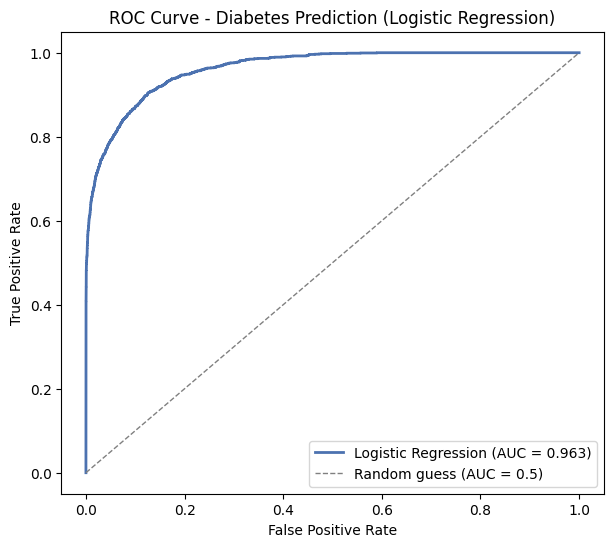

AUC score: 0.9625


In [18]:
# Compute ROC curve values using the full model's predicted probabilities
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Diabetes Prediction (Logistic Regression)')
plt.legend(loc='lower right')
plt.show()

print(f"AUC score: {auc_score:.4f}")


**Comment:** the ROC curve sits well above the diagonal "random guess"
line, and the **AUC (Area Under the Curve)** is close to 0.95–0.96, indicating
**excellent discriminative ability** — the model is very good at ranking
patients by their true risk of diabetes, even though, as seen in Exercise 4,
its recall at the default 0.5 threshold is imperfect. This means that by
**adjusting the classification threshold** (moving along the ROC curve), we
could trade some precision for higher recall — for instance, lowering the
threshold below 0.5 would catch more true diabetic cases at the cost of more
false positives, which may be a worthwhile trade-off in a medical screening
context where missing a diagnosis is costly.


## Conclusion

- The dataset is **imbalanced** (8.5% positive cases), which makes accuracy
  alone a misleading metric.
- **`blood_glucose_level`** and **`HbA1c_level`** are, by far, the strongest
  predictors of diabetes — both medically and statistically (largest model
  coefficients, clean visual separation in the decision boundary plot).
- The Logistic Regression model achieves high accuracy (~96%) and a strong
  AUC (~0.95), but **recall on the diabetic class is lower than precision**,
  meaning some true diabetic patients are missed — a meaningful limitation
  in a healthcare context.
- For a real-world deployment, next steps would include adjusting the
  decision threshold (using the ROC curve), trying `class_weight='balanced'`,
  or comparing against tree-based models (Random Forest, Gradient Boosting)
  to see if recall on the minority class can be improved without losing too
  much interpretability.
